<a href="https://colab.research.google.com/github/Aman2000102/DeepLearning/blob/main/ResNet50_binarycrossentropy_focalloss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import shutil
import numpy as np

# --- Paths and Ratios ---
extracted_path = "/content/drive/MyDrive/Colab Notebooks/covid19normalpneumonia-ct-images"
classesPath = ['Normal_CT', 'pneumonia_CT']
train_ratio, val_ratio, test_ratio = 0.6, 0.2, 0.2

# --- Prepare Balanced Dataset ---
class_file_counts = {}
for cls in classesPath:
    src = os.path.join(extracted_path, cls)
    allFileNames = os.listdir(src)
    class_file_counts[cls] = len(allFileNames)

min_files = min(class_file_counts.values())

for cls in classesPath:
    os.makedirs(os.path.join('./train/', cls), exist_ok=True)
    os.makedirs(os.path.join('./val/', cls), exist_ok=True)
    os.makedirs(os.path.join('./test/', cls), exist_ok=True)

    src = os.path.join(extracted_path, cls)
    allFileNames = os.listdir(src)
    np.random.shuffle(allFileNames)
    balanced_FileNames = allFileNames[:min_files]

    train_count = int(train_ratio * min_files)
    val_count = int(val_ratio * min_files)
    test_count = min_files - train_count - val_count

    # Calculate the split sizes
    total_files = len(balanced_FileNames)
    train_FileNames = balanced_FileNames[:train_count]
    val_FileNames = balanced_FileNames[train_count:train_count + val_count]
    test_FileNames = balanced_FileNames[train_count + val_count:]

    # Print statistics for each class
    print(f'Total {cls} after balancing: {total_files}')
    print(f'Training: {len(train_FileNames)}')
    print(f'Validation: {len(val_FileNames)}')
    print(f'Testing: {len(test_FileNames)}\n')

    for name in train_FileNames:
        shutil.copy(os.path.join(src, name), os.path.join('./train/', cls))
    for name in val_FileNames:
        shutil.copy(os.path.join(src, name), os.path.join('./val/', cls))
    for name in test_FileNames:
        shutil.copy(os.path.join(src, name), os.path.join('./test/', cls))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/covid19normalpneumonia-ct-images/Normal_CT'

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Directories
train_dir = 'train'
val_dir = 'val'
test_dir = 'test'

# Data Generators with 224x224 input
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir, target_size=(128, 128), class_mode='binary', batch_size=16, shuffle=True)
val_generator = val_datagen.flow_from_directory(val_dir, target_size=(128, 128), class_mode='binary', batch_size=16, shuffle=False)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(128, 128), class_mode='binary', batch_size=16, shuffle=False)

Found 2542 images belonging to 2 classes.
Found 846 images belonging to 2 classes.
Found 850 images belonging to 2 classes.


In [ ]:
import numpy as np, tensorflow as tf, tensorflow.keras.backend as K
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import (Dense, Dropout, GlobalAveragePooling2D,
                                     Conv2D, BatchNormalization, Multiply, Reshape)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Hybrid BCE + Focal loss
def hybrid_bce_focal(gamma=2.0, alpha=0.25, focal_weight=0.6):
    bce = tf.keras.losses.BinaryCrossentropy()

    def focal_loss(y_true, y_pred):
        y_true_f = K.cast(y_true, dtype='float32')
        y_pred_f = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())

        pt = tf.where(K.equal(y_true_f, 1), y_pred_f, 1 - y_pred_f)
        loss = -alpha * K.pow(1. - pt, gamma) * K.log(pt)
        return K.mean(loss)

    def loss(y_true, y_pred):
        bce_loss = bce(y_true, y_pred)
        focal = focal_loss(y_true, y_pred)
        return focal_weight * focal + (1 - focal_weight) * bce_loss

    return loss

# --------------------------- SE block ---------------------------
def squeeze_excite(x, r=16):
    f = x.shape[-1]
    se = GlobalAveragePooling2D()(x)
    se = Dense(f // r, activation='relu')(se)
    se = Dense(f, activation='sigmoid')(se)
    se = Reshape((1,1,f))(se)
    return Multiply()([x, se])

# --------------------------- class weights ---------------------------
X_full, y_full = [], []
for i in range(len(train_generator)):
    xb, yb = train_generator[i]
    X_full.append(xb)
    y_full.append(yb)
    if len(X_full) * 16 >= train_generator.n:
        break
X_full = np.concatenate(X_full)
y_full = np.concatenate(y_full)
X_train, _, y_train, _ = train_test_split(X_full, y_full, test_size=0.2, random_state=42)
class_w = dict(enumerate(compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)))

# --------------------------- model ---------------------------
base = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128,3))
for lyr in base.layers[-100:]:
    lyr.trainable = True
x = squeeze_excite(base.output)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
out = Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001))(x)
model = Model(base.input, out)

model.compile(optimizer=Adam(1e-4),
              loss=hybrid_bce_focal(alpha=0.25, gamma=2.0, focal_weight=0.6),
              metrics=['accuracy'])

# --------------------------- callbacks ---------------------------
es = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.3, patience=5, min_lr=1e-7)

# --------------------------- train ---------------------------
history = model.fit(X_train, y_train,
                    epochs=50, batch_size=16,
                    validation_data=val_generator,
                    callbacks=[es, rlr],
                    class_weight=class_w)

# --------------------------- validation ---------------------------
val_pred = (model.predict(val_generator) > 0.5).astype(int)
val_lbl = val_generator.classes
print("Validation:",
      f"Acc {accuracy_score(val_lbl, val_pred):.4f}",
      f"Prec {precision_score(val_lbl, val_pred):.4f}",
      f"Rec {recall_score(val_lbl, val_pred):.4f}",
      f"F1 {f1_score(val_lbl, val_pred):.4f}")

# --------------------------- test ---------------------------
X_test, y_test = [], []
for i in range(len(test_generator)):
    xb, yb = test_generator[i]
    X_test.append(xb); y_test.append(yb)
    if len(X_test) * 16 >= test_generator.n:
        break
X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test)
test_pred = (model.predict(X_test) > 0.5).astype(int)
print("Test:",
      f"Acc {accuracy_score(y_test, test_pred):.4f}",
      f"Prec {precision_score(y_test, test_pred):.4f}",
      f"Rec {recall_score(y_test, test_pred):.4f}",
      f"F1 {f1_score(y_test, test_pred):.4f}")


Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.7392 - loss: 0.2469

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


128/128 ━━━━━━━━━━━━━━━━━━━━ 114s 376ms/step - accuracy: 0.7397 - loss: 0.2466 - val_accuracy: 0.4929 - val_loss: 0.3068 - learning_rate: 1.0000e-04
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 17s 129ms/step - accuracy: 0.9191 - loss: 0.0995 - val_accuracy: 0.4953 - val_loss: 0.3283 - learning_rate: 1.0000e-04
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 19s 115ms/step - accuracy: 0.9616 - loss: 0.0567 - val_accuracy: 0.5154 - val_loss: 0.3376 - learning_rate: 1.0000e-04
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 22s 128ms/step - accuracy: 0.9677 - loss: 0.0422 - val_accuracy: 0.5946 - val_loss: 0.3405 - learning_rate: 1.0000e-04
Epoch 5/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - accuracy: 0.9811 - loss: 0.0258 - val_accuracy: 0.7931 - val_loss: 0.1986 - learning_rate: 1.0000e-04
Epoch 6/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 21s 112ms/step - accuracy: 0.9863 - loss: 0.0229 - val_accuracy: 0.8239 - val_loss: 0.3033 - learning_rate: 1.0000e-04
Epoch 7/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step -

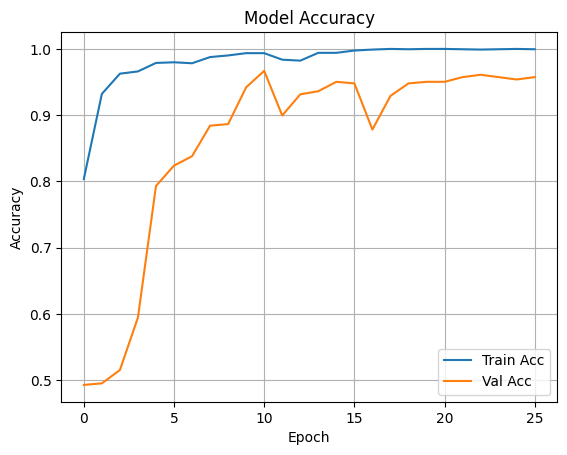

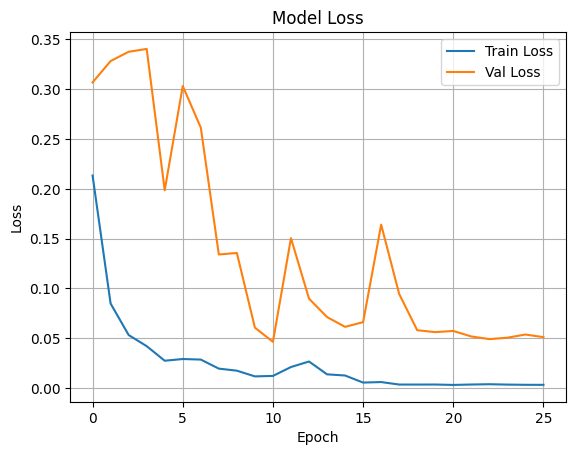

In [ ]:
import matplotlib.pyplot as plt
# --- Plots ---
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step


<Figure size 800x600 with 0 Axes>

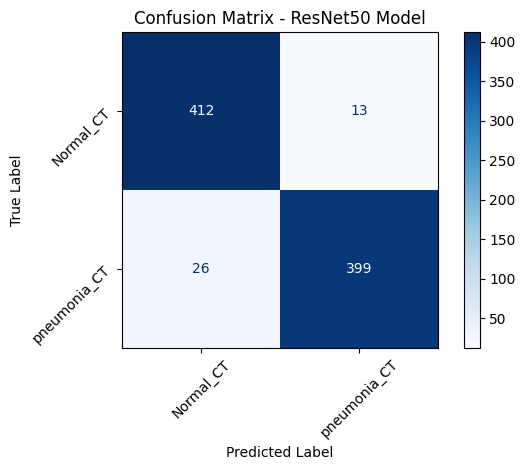

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Evaluate model on test data
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int).ravel()  # Convert probabilities to class labels (0 or 1)

# True labels
y_true = test_generator.classes  # Assuming test_generator has the true labels

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - ResNet50 Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
model.save('ResNet50__binarycrossentropy_focalloss.h5')

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_903']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
<ipython-input-10-28687222a4f1>:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap(cmap)


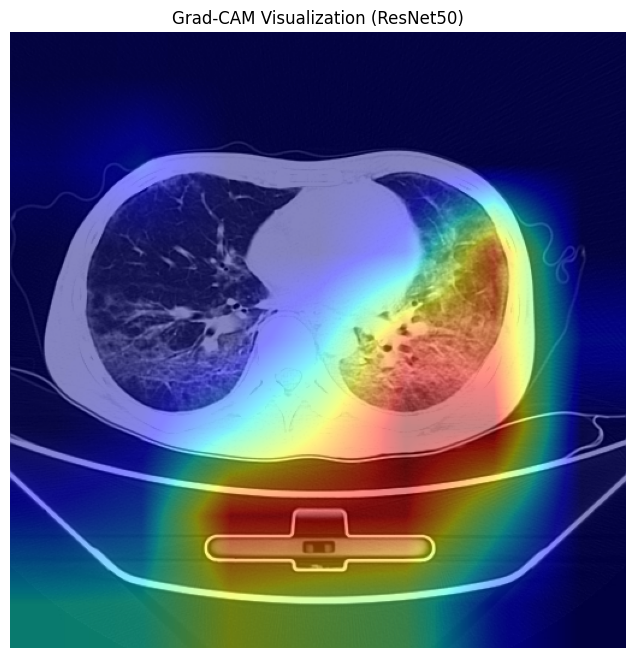

Saved Grad-CAM visualization at: gradcam_output_custom_resnet50.jpg


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import os

model = ResNet50(weights='imagenet')
# Image preprocessing function (for your CT images)
def preprocess_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    return preprocess_input(img_array)

# Grad-CAM generation
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv5_block3_out", pred_index=None):
    grad_model = Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_output = predictions[:, pred_index]

    grads = tape.gradient(class_output, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())
    return heatmap.numpy()

# Overlay heatmap on original image
def overlay_heatmap(heatmap, img_path, alpha=0.4, cmap='jet'):
    img = image.load_img(img_path)
    img = image.img_to_array(img)

    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (img.shape[0], img.shape[1])).numpy()
    heatmap_resized = np.uint8(255 * heatmap_resized[:, :, 0])

    jet = plt.cm.get_cmap(cmap)
    colored_heatmap = jet(heatmap_resized / 255.0)[:, :, :3]
    colored_heatmap = np.uint8(255 * colored_heatmap)

    superimposed_img = img * (1 - alpha) + colored_heatmap * alpha
    superimposed_img = np.clip(superimposed_img, 0, 255).astype("uint8")

    return tf.keras.preprocessing.image.array_to_img(superimposed_img)

# Run visualization
def run_gradcam(img_path, save_path=None):
    img_array = preprocess_image(img_path)
    heatmap = make_gradcam_heatmap(img_array, model)
    superimposed_img = overlay_heatmap(heatmap, img_path)

    # Display the image
    plt.figure(figsize=(8, 8))
    plt.imshow(superimposed_img)
    plt.axis("off")
    plt.title("Grad-CAM Visualization (ResNet50)")
    plt.show()

    # Save the image if a path is given
    if save_path:
        superimposed_img.save(save_path)
        print(f"Saved Grad-CAM visualization at: {save_path}")

# Example image path (replace with your test image)
img_path = "/content/test/pneumonia_CT/200 (43).jpg"

# Run Grad-CAM visualization and save it
run_gradcam(img_path, save_path="gradcam_output_custom_resnet50.jpg")


<ipython-input-10-28687222a4f1>:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap(cmap)


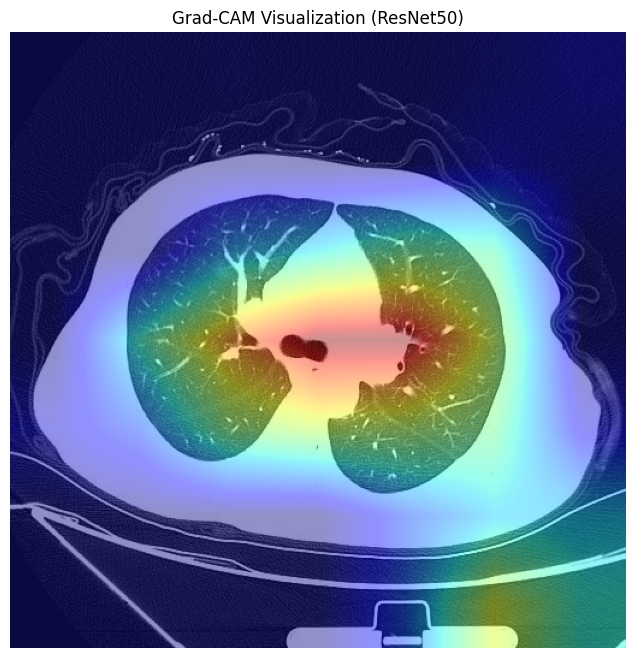

Saved Grad-CAM visualization at: gradcam_output_custom_resnet50.jpg


In [ ]:
img_path = "/content/test/pneumonia_CT/204 (42).jpg"
# Run Grad-CAM visualization and save it
run_gradcam(img_path, save_path="gradcam_output_custom_resnet50.jpg")


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_1080']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
<ipython-input-10-28687222a4f1>:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap(cmap)


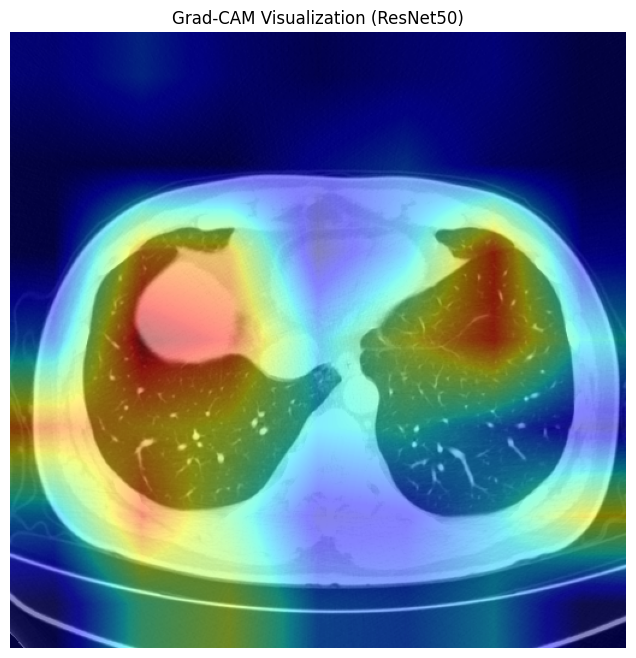

Saved Grad-CAM visualization at: gradcam_output_custom_resnet50.jpg


In [ ]:
img_path = "/content/test/Normal_CT/32004 (48).jpg"
# Run Grad-CAM visualization and save it
run_gradcam(img_path, save_path="gradcam_output_custom_resnet50.jpg")

<ipython-input-10-28687222a4f1>:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap(cmap)


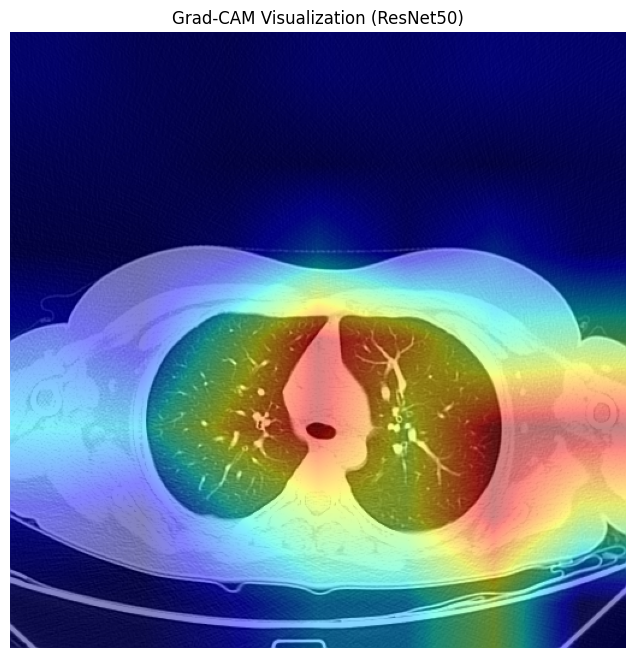

Saved Grad-CAM visualization at: gradcam_output_custom_resnet50.jpg


In [ ]:
img_path = "/content/test/Normal_CT/32014 (21).jpg"
# Run Grad-CAM visualization and save it
run_gradcam(img_path, save_path="gradcam_output_custom_resnet50.jpg")

<ipython-input-14-328e1022d774>:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


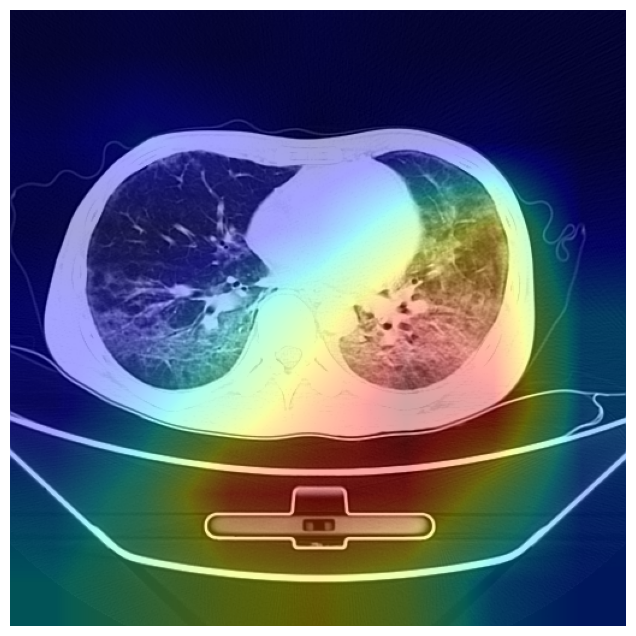

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Load your custom ResNet50 model (use your saved model)
model = ResNet50(weights='imagenet')

# Function to preprocess input image (for your CT images)
def preprocess_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    return preprocess_input(img_array)

# Function to compute Class Activation Mapping (CAM)
def compute_cam(img_array, model, last_conv_layer_name="conv5_block3_out", class_idx=None):
    last_conv_layer = model.get_layer(last_conv_layer_name)
    last_conv_model = tf.keras.models.Model(model.input, last_conv_layer.output)

    classifier_weights = model.layers[-1].get_weights()[0]  # Final dense layer weights

    feature_maps = last_conv_model(img_array)
    predictions = model(img_array)

    if class_idx is None:
        class_idx = np.argmax(predictions[0])

    class_weights = classifier_weights[:, class_idx]

    cam = tf.reduce_sum(feature_maps[0] * class_weights, axis=-1)
    cam = tf.maximum(cam, 0)  # ReLU operation
    cam = cam / tf.reduce_max(cam)
    return cam.numpy()

# Function to overlay CAM on original image
def overlay_cam(cam, img_path, alpha=0.4):
    img = image.load_img(img_path)
    img = image.img_to_array(img)

    cam = np.uint8(255 * cam)
    cam = tf.image.resize(np.expand_dims(cam, axis=-1), (img.shape[0], img.shape[1])).numpy()
    cam = np.uint8(cam[:, :, 0])

    jet = plt.cm.get_cmap("jet")
    jet_heatmap = jet(np.arange(256))[:, :3]
    jet_heatmap = np.uint8(jet_heatmap * 255)
    colored_heatmap = jet_heatmap[cam]

    superimposed_img = colored_heatmap * alpha + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)
    return superimposed_img

# Test with an example image
img_path = "/content/test/pneumonia_CT/200 (43).jpg"  # Replace with your image path
img_array = preprocess_image(img_path)

# Get CAM heatmap
cam = compute_cam(img_array, model, last_conv_layer_name="conv5_block3_out")

# Overlay CAM on image
superimposed_img = overlay_cam(cam, img_path)

# Display the image
plt.figure(figsize=(8, 8))
plt.imshow(superimposed_img)
plt.axis("off")
plt.show()


<ipython-input-14-328e1022d774>:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


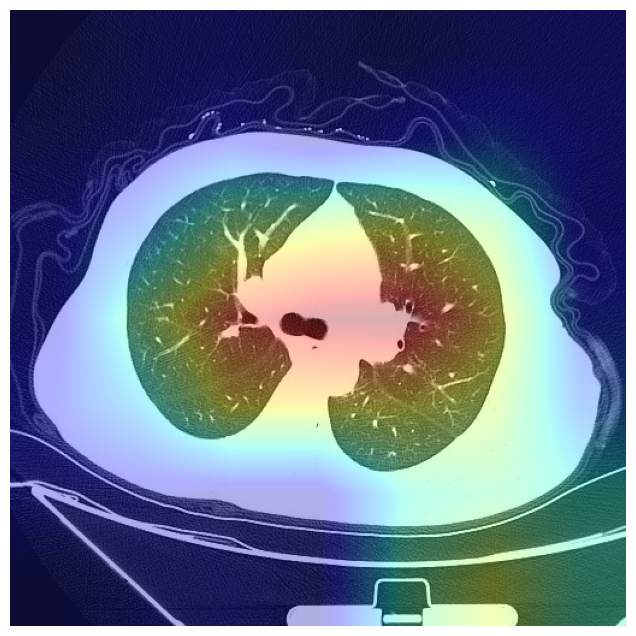

In [ ]:
 #Test with an example image
img_path = "/content/test/pneumonia_CT/204 (42).jpg"  # Replace with your image path
img_array = preprocess_image(img_path)

# Get CAM heatmap
cam = compute_cam(img_array, model, last_conv_layer_name="conv5_block3_out")

# Overlay CAM on image
superimposed_img = overlay_cam(cam, img_path)

# Display the image
plt.figure(figsize=(8, 8))
plt.imshow(superimposed_img)
plt.axis("off")
plt.show()

<ipython-input-14-328e1022d774>:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


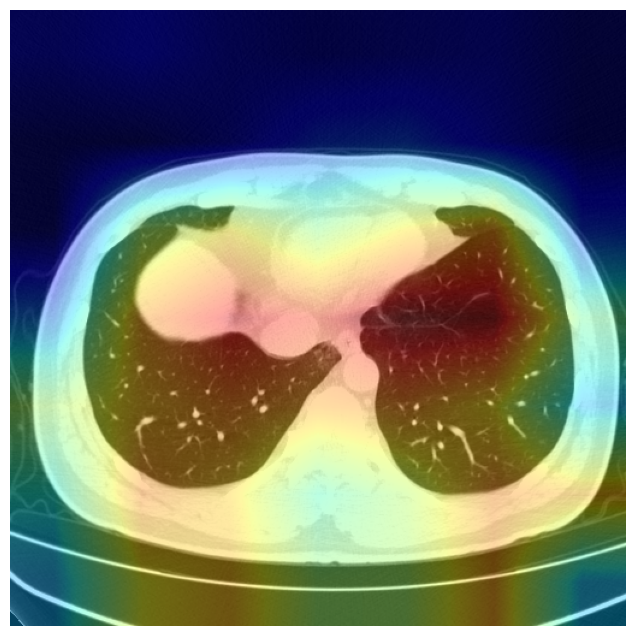

In [ ]:
 #Test with an example image
img_path = "/content/test/Normal_CT/32004 (48).jpg"  # Replace with your image path
img_array = preprocess_image(img_path)

# Get CAM heatmap
cam = compute_cam(img_array, model, last_conv_layer_name="conv5_block3_out")

# Overlay CAM on image
superimposed_img = overlay_cam(cam, img_path)

# Display the image
plt.figure(figsize=(8, 8))
plt.imshow(superimposed_img)
plt.axis("off")
plt.show()

<ipython-input-14-328e1022d774>:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


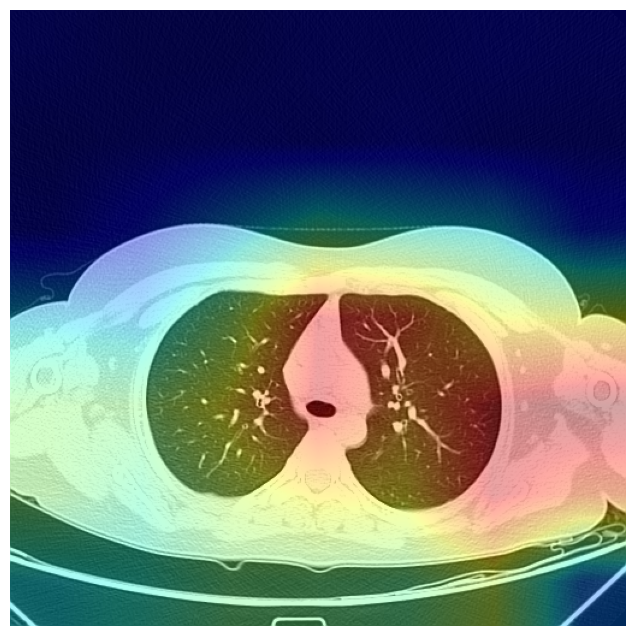

In [ ]:
# Test with an example image
img_path = "/content/test/Normal_CT/32014 (21).jpg"  # Replace with your image path
img_array = preprocess_image(img_path)

# Get CAM heatmap
cam = compute_cam(img_array, model, last_conv_layer_name="conv5_block3_out")

# Overlay CAM on image
superimposed_img = overlay_cam(cam, img_path)

# Display the image
plt.figure(figsize=(8, 8))
plt.imshow(superimposed_img)
plt.axis("off")
plt.show()

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 11.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=f5784948152e45a520b804faaaffa1c079b96e1619254afad5c593c9a774b8d1
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


102869336/102869336 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Predicted: [('n03584254', 'iPod', np.float32(0.24567059)), ('n03447721', 'gong', np.float32(0.09577044)), ('n04192698', 'shield', np.float32(0.0681154))]


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━

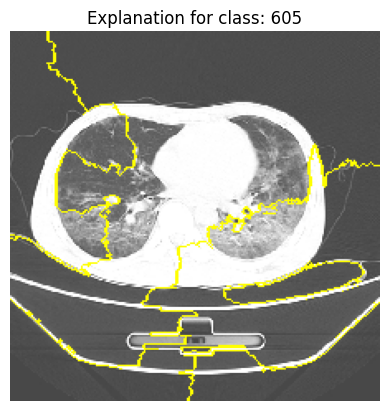

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted: [('n04019541', 'puck', np.float32(0.32117563)), ('n03223299', 'doormat', np.float32(0.23030835)), ('n02877765', 'bottlecap', np.float32(0.06916869))]


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━

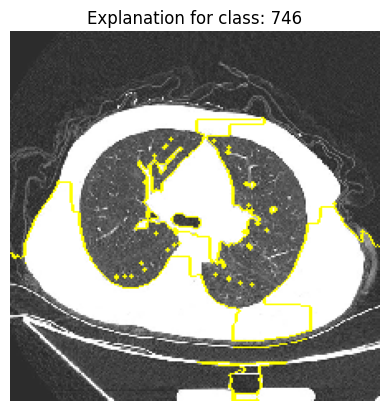

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted: [('n07836838', 'chocolate_sauce', np.float32(0.67218184)), ('n07614500', 'ice_cream', np.float32(0.046477824)), ('n03929660', 'pick', np.float32(0.04447058))]


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━

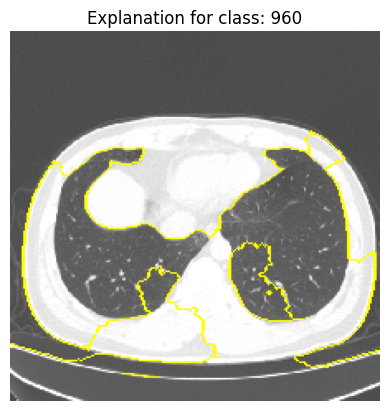

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted: [('n02910353', 'buckle', np.float32(0.9542305)), ('n03476684', 'hair_slide', np.float32(0.007062471)), ('n15075141', 'toilet_tissue', np.float32(0.004297009))]


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━

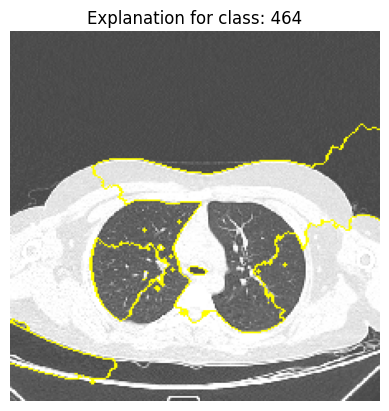

In [ ]:
#Applying LIME XAI technique

import numpy as np
import matplotlib.pyplot as plt
from keras.preprocessing import image
from lime import lime_image
from skimage.segmentation import mark_boundaries

def explain_image_with_lime(model, img_path):
    """
    Explains the prediction of a model on a given image using LIME.

    Parameters:
    - model: A pre-trained model that will be used to make predictions.
    - img_path: The path to the image to be explained.

    Returns:
    - None: The function displays the image with LIME explanations.
    """

    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))  # Adjust the target size according to your model
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = model.preprocess_input(img_array)  # Replace with your model's preprocess function if needed

    # Get the model's prediction
    preds = model.predict(img_array)
    print('Predicted:', model.decode_predictions(preds, top=3)[0])  # Adjust this according to your model

    # Initialize LIME image explainer
    explainer = lime_image.LimeImageExplainer()

    # Explain the prediction
    explanation = explainer.explain_instance(
        img_array[0].astype('double'),
        model.predict,
        top_labels=5,
        hide_color=0,
        num_samples=1000
    )

    # Get the explanation for the top predicted label
    top_label = np.argmax(preds)
    temp, mask = explanation.get_image_and_mask(
        top_label,
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    # Display the image with boundaries
    plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
    plt.title(f"Explanation for class: {top_label}")
    plt.axis('off')
    plt.show()

# Example usage:
if __name__ == "__main__":
    from tensorflow.keras.applications.resnet_v2 import ResNet50V2, preprocess_input, decode_predictions
    model = ResNet50V2(weights='imagenet')
    model.preprocess_input = preprocess_input  # Add preprocess and decode functions to the model object
    model.decode_predictions = decode_predictions

    img_path = '/content/test/pneumonia_CT/200 (43).jpg'

     # Call the function to explain the image
    explain_image_with_lime(model, img_path)

    img_path2 = '/content/test/pneumonia_CT/204 (42).jpg'

     # Call the function to explain the image
    explain_image_with_lime(model, img_path2)

    img_path3 = '/content/test/Normal_CT/32004 (48).jpg'

     # Call the function to explain the image
    explain_image_with_lime(model, img_path3)

    img_path4 = '/content/test/Normal_CT/32014 (21).jpg'

     # Call the function to explain the image
    explain_image_with_lime(model, img_path4)
